# Customer Segmentation Final Project + Analysis

### 3. IMPORT LIBRARIES

In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### 4. LOAD THE DATASET

In [189]:
df = pd.read_csv("Mall_Customers.csv")

##### Inspect it:

In [190]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [191]:
df.shape

(200, 5)

In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [193]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### 5. DATA QUALITY CHECK

In [194]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [195]:
df.duplicated().sum()

np.int64(0)

In [196]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

### 6. SELECT FEATURES

In [197]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

##### Inspect:

In [198]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### 7. VISUALIZE BEFORE CLUSTERING

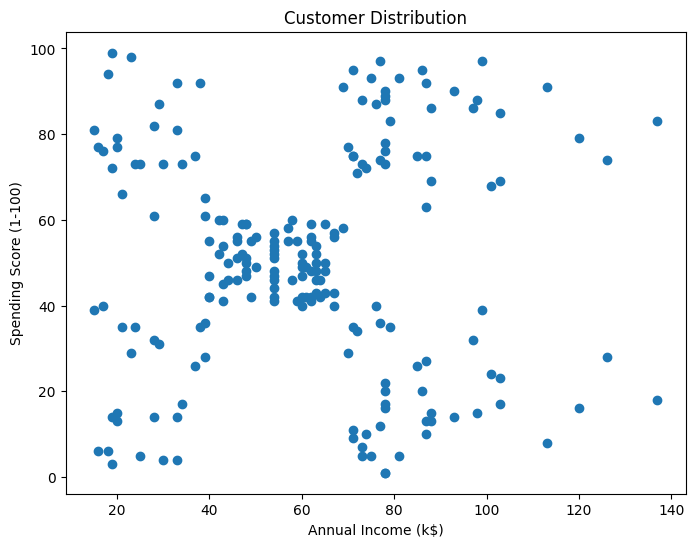

In [199]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Distribution")

plt.show()

### 8. FEATURE SCALING

In [200]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

##### Check:

In [201]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

### 9. FIND THE BEST NUMBER OF CLUSTERS

#### Method 1 - Elbow Method

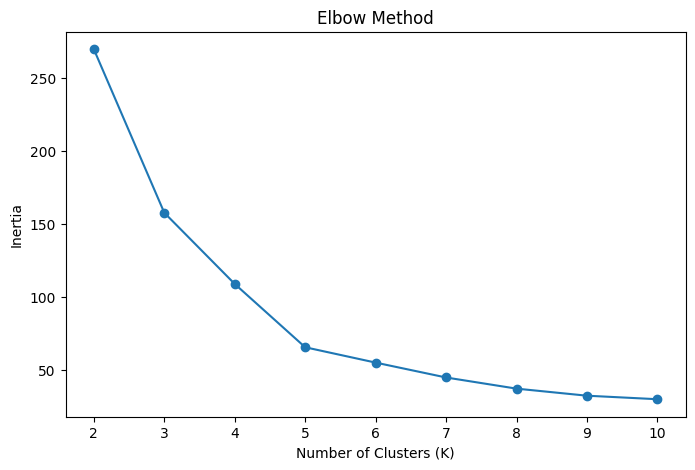

In [202]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

### 10. SILHOUETTE SCORE

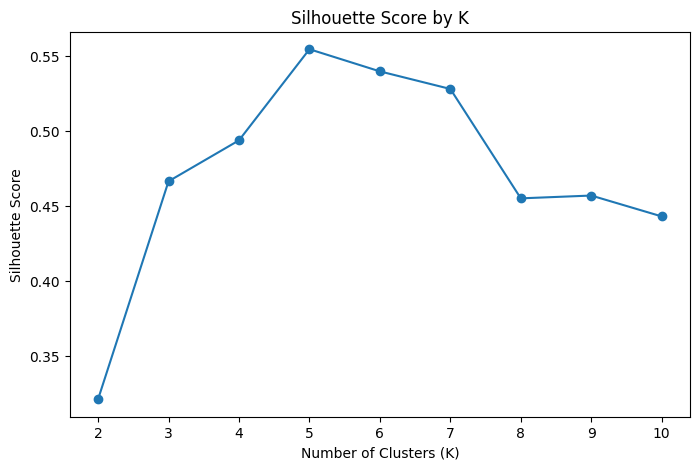

In [203]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)


plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker = "o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")

plt.show()

### 12. TRAIN THE FINAL K-MEANS MODEL

In [204]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

#### Add the cluster labels:

In [205]:
df["Cluster"] = clusters

##### Check

In [206]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### 13. VISUALIZE THE FINAL CLUSTERS

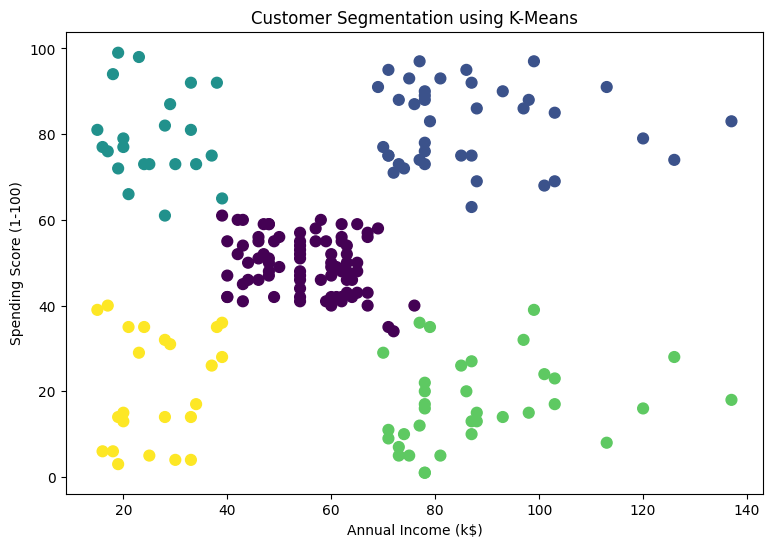

In [207]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()

### 14. VISUALIZE THE CENTROIDS

Get the centroids:

In [208]:
centers_scaled = kmeans.cluster_centers_

Because these are in scaled space, convert them back:

In [209]:
centers = scaler.inverse_transform(centers_scaled)

Plot:

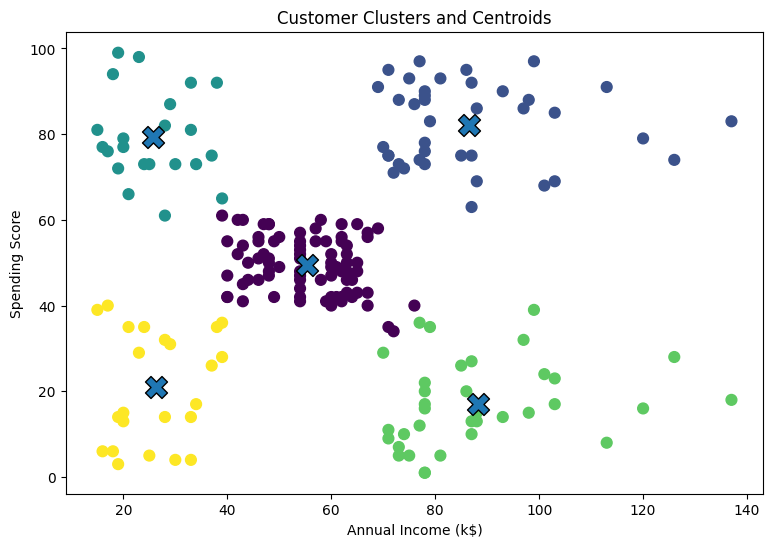

In [210]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=60
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    edgecolor="black"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Clusters and Centroids")

plt.show()

### 15. CLUSTER SIZE

Now ask:

How many customers are in each cluster?

In [211]:
df["Cluster"].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

You can also visualize this:

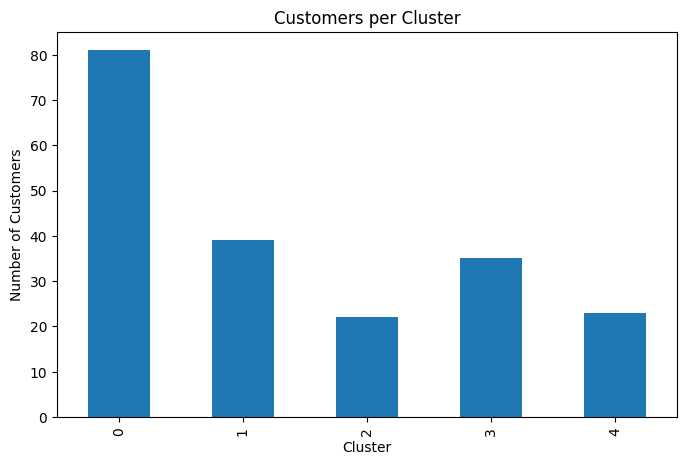

In [212]:
df["Cluster"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customers per Cluster")

plt.show()

This is useful because a cluster containing:

5 customers

has a very different business significance from a cluster containing:

500 customers

### 16. CLUSTER PROFILING ⭐

This is one of the most important parts of today's lesson.

K-Means gives you cluster IDs.

Now you need to understand them.

Calculate cluster averages:

In [213]:
cluster_profile = df.groupby("Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean()

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043
